In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
#load dataset
df=pd.read_csv('/content/iris (1).csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.shape

(150, 5)

In [7]:
print("No of Duplicated Records:",df.duplicated().sum())

No of Duplicated Records: 3


In [9]:
#drop duplicates
df.drop_duplicates(inplace=True)
df.shape

(147, 5)

In [10]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<Axes: ylabel='sepal_length'>

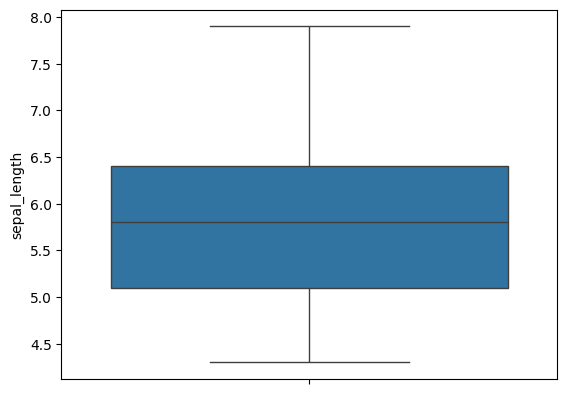

In [11]:
#identify outliers
sns.boxplot(df['sepal_length'])

<Axes: ylabel='sepal_width'>

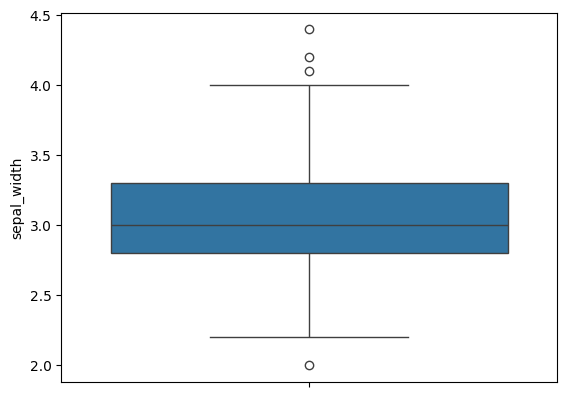

In [12]:
#identfy outliers in sepal width
sns.boxplot(df['sepal_width'])

In [13]:
#remove outliers in sepal width
Q1=df['sepal_width'].quantile(0.25)
Q3=df['sepal_width'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
df=df[(df['sepal_width']>=lower_limit)&(df['sepal_width']<=upper_limit)]
df.shape

(143, 5)

<Axes: ylabel='sepal_width'>

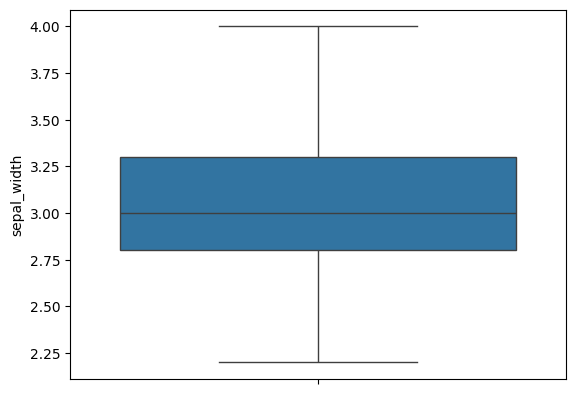

In [14]:
#outliers in sepal width
sns.boxplot(df['sepal_width'])

<Axes: ylabel='petal_length'>

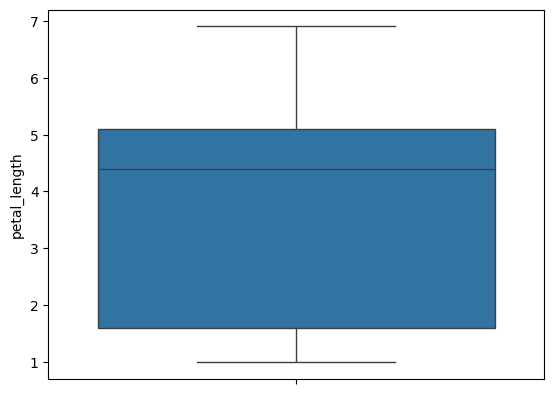

In [15]:
#outliers in petal length
sns.boxplot(df['petal_length'])

<Axes: ylabel='petal_width'>

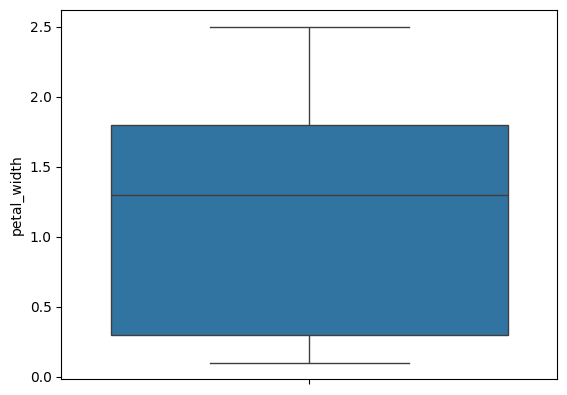

In [16]:
#outliers in petal width
sns.boxplot(df['petal_width'])

In [17]:
#label encoding for target
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['species']=le.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [18]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [20]:
#split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=15)

In [21]:
#Standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [22]:
#model building
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [23]:
#predictions on test data
y_pred=knn.predict(x_test)

In [24]:
#evaluation metrics
accuracy_score(y_test,y_pred)
classification_report(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[ 8,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  8]])

<Axes: >

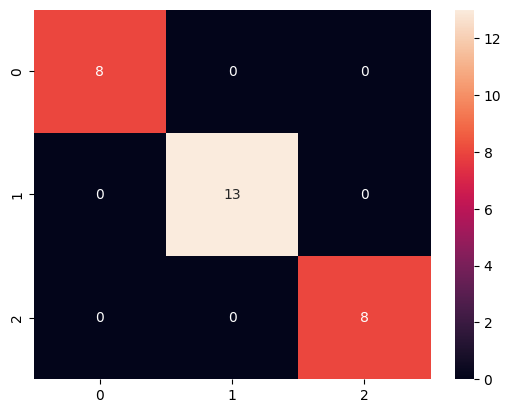

In [25]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(y_test,y_proba,multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

Accuracy: 1.0
ROC-AUC Score: 1.0


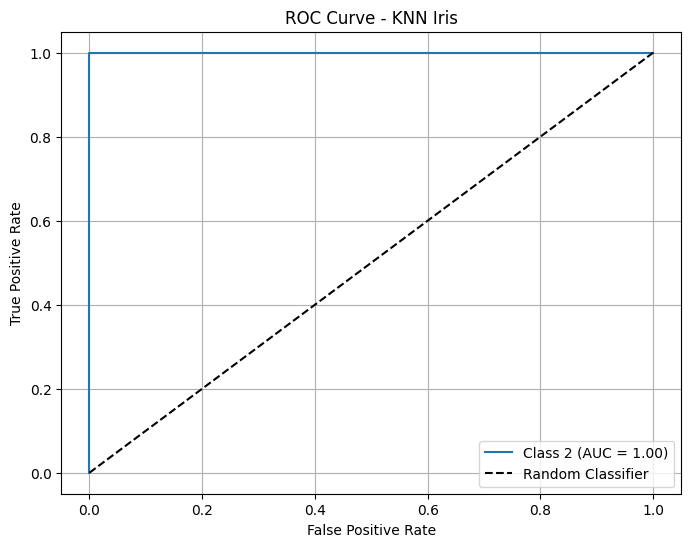

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Predict probabilities
y_proba = knn.predict_proba(x_test)
# Convert test labels into binary form
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(3):
  fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
plt.plot(
fpr, tpr,
label=f'Class {i} (AUC = {auc_score:.2f})'
)
# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Iris')
plt.legend()
plt.grid()
plt.show()

In [33]:
overall_auc = roc_auc_score(
y_test_bin,

y_proba,
multi_class='ovr'
)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 1.0
